# 🎯 Bellman Equations: From MDPs to Optimal Decisions

Welcome! In your previous lecture you saw **Markov Decision Processes (MDPs)** — the mathematical framework for sequential decision-making under uncertainty.
This notebook will introduce you to the **Bellman equations**, the foundation of almost every reinforcement-learning algorithm.

### What you will do (≈ 45 minutes)
1. Recap MDPs by setting up a tiny **4×4 gridworld**.
2. Build intuition for **value functions** — how good is it to be in a given state?
3. Implement **iterative policy evaluation** using the Bellman *expectation* equation.
4. Implement **value iteration** using the Bellman *optimality* equation.
5. Recover the **optimal policy** and visualize it.

### How this notebook works
Most of the code is already written for you. You only need to fill in **four blanks** marked
`# 🎯 YOUR CODE HERE`. Each blank is a handful of lines; read the math equation right above
the exercise — your code is almost always a direct translation of the symbols.

To run a cell: click on it and press **Shift + Enter**.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(0)
plt.rcParams['figure.dpi'] = 90
print("✅ Libraries loaded.")

✅ Libraries loaded.


## 1. Quick MDP Recap

A Markov Decision Process is described by 5 things:

| Symbol | Name | Meaning |
|---|---|---|
| $\mathcal{S}$ | states | the situations the agent can be in |
| $\mathcal{A}$ | actions | what the agent can choose to do |
| $P(s' \mid s, a)$ | transitions | what happens after an action |
| $R(s, a)$ | reward | the signal that tells the agent "good" or "bad" |
| $\gamma \in [0,1)$ | discount | how much we value future vs immediate reward |

The agent acts according to a **policy** $\pi(a \mid s)$ — a (possibly random) rule for picking actions given the current state.

> 🤔 **Why a discount $\gamma$?**
> - Mathematically, it keeps the infinite sum of future rewards finite.
> - Intuitively, $\gamma$ close to 1 means the agent is *patient*; close to 0 means *short-sighted*.


## 2. Our Playground — a 4×4 Gridworld

We will work with the simplest interesting MDP: a grid where the agent moves **up / right / down / left**.

```
 .   .   .   .       <- row 0 (top)
 .   .  🔴   .
 .   .   .   .
 .   .   .  🟢      <- row 3 (bottom)
```

- 🟢 **Goal** at `(3,3)` → reward **+10**, episode ends.
- 🔴 **Pit** at `(1,2)` → reward **−10**, episode ends.
- 🚶 Every other step → reward **−1** (a small "cost of living" so the agent doesn't waste time).
- Walls are solid: bumping into one keeps you in place.
- Transitions are **deterministic** — chosen actions always succeed (no slipping). This keeps the math simple; the same ideas extend to stochastic transitions.

We discount future rewards with $\gamma = 0.9$.


In [21]:
# ===== Gridworld constants =====
GRID_SIZE = 4
N_STATES  = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4
ACTION_NAMES  = ['↑ up', '→ right', '↓ down', '← left']
ACTION_DELTAS = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}  # (Δrow, Δcol)

GOAL  = (3, 3)
PIT   = (1, 2)
GAMMA = 0.9


# ===== Helpers =====
def state_to_idx(row, col):
    """Turn a (row, col) into a flat state index 0..15."""
    return row * GRID_SIZE + col


def idx_to_state(idx):
    """Turn a flat state index back into (row, col)."""
    return idx // GRID_SIZE, idx % GRID_SIZE


def is_terminal(row, col):
    return (row, col) == GOAL or (row, col) == PIT


def step(row, col, action):
    """One environment step. Returns (next_row, next_col, reward, done)."""
    if is_terminal(row, col):
        return row, col, 0.0, True  # terminal states absorb
    dr, dc = ACTION_DELTAS[action]
    new_row = max(0, min(GRID_SIZE - 1, row + dr))
    new_col = max(0, min(GRID_SIZE - 1, col + dc))
    if (new_row, new_col) == GOAL:
        return new_row, new_col, 10.0, True
    if (new_row, new_col) == PIT:
        return new_row, new_col, -10.0, True
    return new_row, new_col, -1.0, False


print("✅ Gridworld defined.")

✅ Gridworld defined.


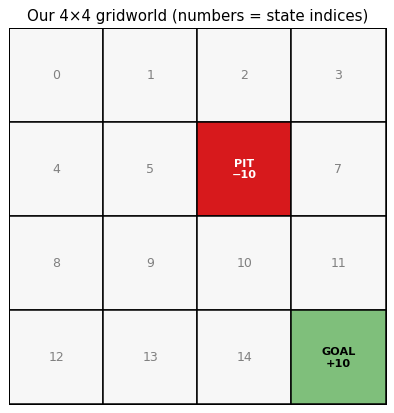

In [22]:
def plot_grid(V=None, policy=None, title="Gridworld", ax=None, show_idx=False):
    """Render the gridworld.
       * If V is given, shade cells by value and write the value inside each cell.
       * If policy is given, draw an arrow showing the most-likely action.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(4.7, 4.7))
    cmap = plt.cm.RdYlGn

    if V is not None:
        non_term = [V[state_to_idx(r, c)]
                    for r in range(GRID_SIZE) for c in range(GRID_SIZE)
                    if not is_terminal(r, c)]
        vmin, vmax = min(non_term), max(non_term)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            y = GRID_SIZE - 1 - r  # invert so row 0 is at the top
            if (r, c) == GOAL:
                color = '#7fbf7b'
            elif (r, c) == PIT:
                color = '#d7191c'
            elif V is not None:
                t = (V[state_to_idx(r, c)] - vmin) / (vmax - vmin + 1e-9)
                color = cmap(0.15 + 0.7 * t)
            else:
                color = '#f7f7f7'
            ax.add_patch(patches.Rectangle((c, y), 1, 1, lw=1.2,
                                           edgecolor='black', facecolor=color))
            cx, cy = c + 0.5, y + 0.5

            if (r, c) == GOAL:
                ax.text(cx, cy, "GOAL\n+10", ha='center', va='center',
                        fontsize=9, fontweight='bold')
            elif (r, c) == PIT:
                ax.text(cx, cy, "PIT\n−10", ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
            else:
                if V is not None and policy is not None:
                    ax.text(cx, cy + 0.22, f"{V[state_to_idx(r, c)]:.2f}",
                            ha='center', va='center', fontsize=9, fontweight='bold')
                    best_a = int(np.argmax(policy[state_to_idx(r, c)]))
                    dr, dc = ACTION_DELTAS[best_a]
                    ax.arrow(cx - dc * 0.12, cy - 0.22 + dr * 0.12,
                             dc * 0.24, -dr * 0.24,
                             head_width=0.1, head_length=0.1,
                             fc='black', ec='black', length_includes_head=True)
                elif V is not None:
                    ax.text(cx, cy, f"{V[state_to_idx(r, c)]:.2f}",
                            ha='center', va='center', fontsize=11, fontweight='bold')
                elif policy is not None:
                    best_a = int(np.argmax(policy[state_to_idx(r, c)]))
                    dr, dc = ACTION_DELTAS[best_a]
                    ax.arrow(cx - dc * 0.2, cy + dr * 0.2,
                             dc * 0.4, -dr * 0.4,
                             head_width=0.14, head_length=0.14,
                             fc='black', ec='black', length_includes_head=True)
                elif show_idx:
                    ax.text(cx, cy, str(state_to_idx(r, c)),
                            ha='center', va='center', fontsize=10, color='gray')

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12)
    return ax


plot_grid(title="Our 4×4 gridworld (numbers = state indices)", show_idx=True)
plt.tight_layout()
plt.show()

## 3. Trajectories, Rewards, and Returns

When the agent follows a policy $\pi$, it produces a **trajectory**:
$$ s_0,\; a_0,\; r_1,\; s_1,\; a_1,\; r_2,\; s_2,\; \ldots $$

The **return** $G$ is the **discounted sum of rewards** along the trajectory:
$$ G \;=\; r_1 \;+\; \gamma\, r_2 \;+\; \gamma^2\, r_3 \;+\; \gamma^3\, r_4 \;+\; \ldots $$

> 🔍 **Why discount?** Suppose $\gamma = 0.9$. A reward of $+10$ right now is worth $10$.
> The same reward $3$ steps from now is worth $0.9^3 \cdot 10 \approx 7.29$.
> Future rewards still count — but **less**.

Let's first try a **uniform random policy**: at any state, pick each of the 4 actions with probability $1/4$.


In [23]:
# Uniform random policy: every action has probability 1/4 in every state.
random_policy = np.ones((N_STATES, N_ACTIONS)) / N_ACTIONS


def simulate(policy, start=(0, 0), max_steps=50):
    """Roll out a single trajectory. Returns (positions, rewards)."""
    row, col = start
    positions = [(row, col)]
    rewards = []
    for _ in range(max_steps):
        s = state_to_idx(row, col)
        a = np.random.choice(N_ACTIONS, p=policy[s])
        row, col, r, done = step(row, col, a)
        positions.append((row, col))
        rewards.append(r)
        if done:
            break
    return positions, rewards


positions, rewards = simulate(random_policy, start=(0, 0))
print("Trajectory (positions):", positions)
print("Rewards collected:     ", rewards)
print("Naive sum of rewards (no discount):", sum(rewards))

Trajectory (positions): [(0, 0), (1, 0), (2, 0), (3, 0), (3, 0), (3, 1), (3, 1), (3, 2), (3, 1), (3, 0), (3, 1), (3, 0), (3, 0), (3, 0), (3, 0), (2, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (1, 0), (1, 1), (1, 2)]
Rewards collected:      [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -10.0]
Naive sum of rewards (no discount): -40.0


### 🎯 Exercise 1 — Compute the discounted return

Implement the function below from the equation:

$$G \;=\; \sum_{t=0}^{T-1} \gamma^{\,t} \cdot r_t$$

`rewards` is a list `[r_0, r_1, r_2, …, r_{T-1}]` and `gamma` is the discount factor.
Translate the equation into a few lines of Python — there is more than one way.

> 💭 *Think before you code.* If `rewards = [1, 1, 1, 1]` and `gamma = 0.9`, what should `G` be?


In [24]:
def compute_return(rewards, gamma):
    """Compute the discounted return G = r0 + γ r1 + γ² r2 + …

    Args:
        rewards: a list of numbers
        gamma:   discount factor in [0, 1)
    Returns:
        the scalar return G
    """
    G = 0.0
    # ============================================================
    # 🎯 YOUR CODE HERE  (a few lines)
    # Build G from the formula above. `gamma ** t` raises gamma to power t.
    # --- 🎯🎯🎯🎯 ---
    for t in range(len(rewards)):
      G = G + gamma ** t * rewards[t]
    return G


# --- Quick test ---
test_rewards = [1, 1, 1, 1]
got      = compute_return(test_rewards, gamma=0.9)
expected = 1 + 0.9 + 0.81 + 0.729  # = 3.439
print(f"Your return: {got:.4f}   (expected {expected:.4f})")
assert abs(got - expected) < 1e-3, "❌ Not quite — check the loop / the powers of γ."
print("✅ Exercise 1 passed!")

# Apply to our random trajectory above
G_random = compute_return(rewards, GAMMA)
print(f"\nReturn of the random trajectory above: {G_random:.3f}")

Your return: 3.4390   (expected 3.4390)
✅ Exercise 1 passed!

Return of the random trajectory above: -10.000


## 4. Value Functions — How Good Is a State?

The **state-value function** under policy $\pi$ is the **expected return** starting from state $s$:

$$ V^\pi(s) \;=\; \mathbb{E}_\pi\!\big[\, G \;\big|\; s_0 = s\,\big] $$

In plain English: *"If I start at state $s$ and act according to $\pi$ forever, how much reward do I get **on average**?"*

We could **estimate** $V^\pi(s)$ by running many trajectories and averaging their returns. Let's try that for the random policy starting at `(0,0)`.


In [25]:
def mc_estimate_v(policy, start, n_episodes=2000):
    returns = []
    for _ in range(n_episodes):
        _, rs = simulate(policy, start=start)
        returns.append(compute_return(rs, GAMMA))
    return np.mean(returns), np.std(returns)


mean_v, std_v = mc_estimate_v(random_policy, start=(0, 0), n_episodes=2000)
print(f"Monte-Carlo estimate of V^π((0,0)) for the random policy:")
print(f"   {mean_v:.2f}  ± {std_v:.2f}   (averaged over 2000 trajectories)")

Monte-Carlo estimate of V^π((0,0)) for the random policy:
   -9.34  ± 1.89   (averaged over 2000 trajectories)


Monte Carlo **works**, but it is slow and noisy: many trajectories per state, and high variance.
**Richard Bellman** (1957) found a much better idea.

### The Bellman Expectation Equation

The value of state $s$ can be written **recursively**:

$$
\boxed{\,V^\pi(s) \;=\; \sum_a \pi(a \mid s)\,\Big[\,R(s, a) \;+\; \gamma \sum_{s'} P(s' \mid s, a)\, V^\pi(s')\,\Big]\,}
$$

**Read this aloud in English:**

> *"The value of state $s$ is the average — over actions the policy might pick — of: the immediate reward, plus the discounted value of the next state."*

#### Why is this so useful?
We've turned an *infinite* sum of future rewards into a **one-step look-ahead**.
Instead of simulating forever, we only need the value of neighbouring states.

#### Specialised to our gridworld
Because our environment is deterministic, the inner sum over $s'$ collapses: there is exactly one next state $s' = \text{step}(s, a)$. The equation simplifies to:

$$ V^\pi(s) \;=\; \sum_a \pi(a \mid s)\,\big[\,R(s, a) + \gamma\, V^\pi(s')\,\big] $$

This is what we will implement.

### How do we *use* the equation? — Iterative policy evaluation
1. Start with $V(s) = 0$ everywhere.
2. For every state, replace $V(s)$ by the right-hand side, computed with the current $V$.
3. Repeat until $V$ stops changing.

That's it. Each sweep is called a **Bellman update**.


### 🎯 Exercise 2 — One Bellman update (policy evaluation)

The function below performs **one full sweep** of policy evaluation: for every non-terminal state $s$, it updates $V(s)$ using the Bellman expectation equation. You need to fill in the body that computes `V_new[s]`.

You will need to:
1. Loop over each action `a` in `range(N_ACTIONS)`.
2. Use `step(row, col, a)` to find the next position and the reward.
3. Convert the next position into a state index with `state_to_idx(...)`.
4. Accumulate the Bellman terms: $\pi(a \mid s)\big[R(s,a) + \gamma\, V(s')\big]$.

Useful Python translations of the math:
- $\pi(a \mid s) \to$ `policy[s, a]`
- $R(s, a) \to$ `reward`
- $V(s') \to$ `V[s_next]`


In [26]:
def bellman_expectation_update(V, policy, gamma):
    """One full sweep of iterative policy evaluation.
    Returns a new value vector V_new of length N_STATES.
    """
    V_new = np.zeros_like(V)
    for s in range(N_STATES):
        row, col = idx_to_state(s)
        if is_terminal(row, col):
            V_new[s] = 0.0          # terminal states have value 0 by convention
            continue

        # ============================================================
        # 🎯 YOUR CODE HERE  (~ 5 lines)
        # Compute V_new[s] from the Bellman expectation equation.
        # Tip: use an accumulator, loop over actions, call step() inside.
        for a in range(N_ACTIONS):
            next_row, next_col, reward, done = step(row, col, a)  #includes the reward
            s_next = state_to_idx(next_row, next_col)
            V_new[s] += reward + V_new[s_next] * gamma # replace
        # --- 🎯🎯🎯🎯 ---
    return V_new


# --- Run iterative policy evaluation ---
V = np.zeros(N_STATES)
v_start_per_iter = [V[state_to_idx(0, 0)]]
for it in range(500):
    V_new = bellman_expectation_update(V, random_policy, GAMMA)
    v_start_per_iter.append(V_new[state_to_idx(0, 0)])
    if np.max(np.abs(V_new - V)) < 1e-7:
        break
    V = V_new

print(f"Converged in {it + 1} sweeps.")
print(f"V^π((0,0))  Bellman:      {V[state_to_idx(0, 0)]:.3f}")
print(f"V^π((0,0))  Monte Carlo:  {mean_v:.3f}")
print("(They should be very close.)")

Converged in 2 sweeps.
V^π((0,0))  Bellman:      -6.700
V^π((0,0))  Monte Carlo:  -9.335
(They should be very close.)


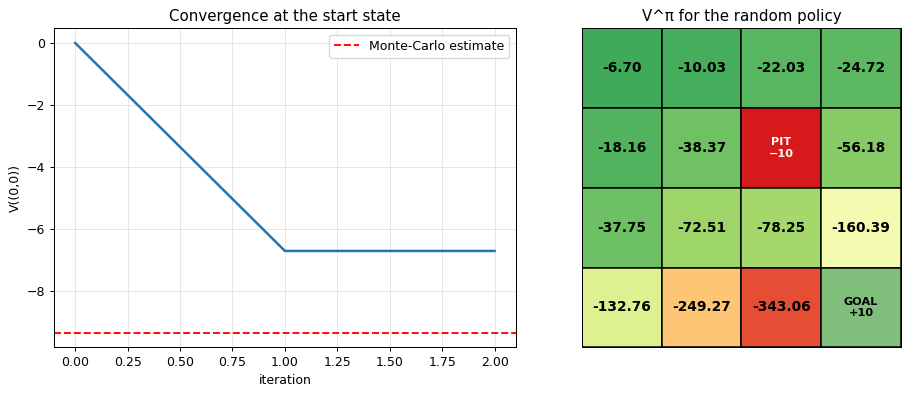

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(v_start_per_iter, lw=2)
axes[0].axhline(mean_v, color='red', ls='--', label='Monte-Carlo estimate')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('V((0,0))')
axes[0].set_title('Convergence at the start state')
axes[0].legend()
axes[0].grid(alpha=0.3)

plot_grid(V=V, title="V^π for the random policy", ax=axes[1])
plt.tight_layout()
plt.show()

## 5. From Evaluating to Optimizing

The Bellman *expectation* equation tells us how good a **given** policy is. But what we really want is the **best** policy — one that gets the most reward.

Look at the heatmap above: under the random policy, almost every state has a negative value because the agent often wanders into the pit. **We can do much better.**

### The Bellman Optimality Equation

Instead of *averaging* over actions, the optimal value $V^*$ **picks the best action** at every state:

$$
\boxed{\,V^*(s) \;=\; \max_a \Big[\, R(s, a) \;+\; \gamma \sum_{s'} P(s' \mid s, a)\, V^*(s')\,\Big]\,}
$$

In our deterministic gridworld:

$$ V^*(s) \;=\; \max_a \big[\, R(s, a) + \gamma\, V^*(s')\,\big] $$

The trick is the same: we turn the problem of "find the optimal infinite-horizon return" into a *recursive* one-step look-ahead — but now with a `max` instead of an expectation.

### The algorithm: Value Iteration
1. Initialise $V$ to zeros.
2. Repeatedly apply the Bellman optimality update.
3. When $V$ stops changing, it equals $V^*$.
4. Extract the policy by taking the action that achieves the `max` in every state.


### 🎯 Exercise 3 — One Bellman optimality update

Implement the body of `bellman_optimality_update`. The structure is almost the same as Exercise 2, but instead of averaging with the policy, you **take the `max` over actions**.

Recommended approach:
1. For each action, compute the *Q-value* $Q(s, a) = R(s, a) + \gamma\, V(s')$.
2. Collect all four Q-values (e.g. into a list).
3. Set `V_new[s]` to the maximum.


In [28]:
def bellman_optimality_update(V, gamma):
    """One sweep of value iteration. Returns the new V."""
    V_new = np.zeros_like(V)
    for s in range(N_STATES):
        row, col = idx_to_state(s)
        if is_terminal(row, col):
            V_new[s] = 0.0
            continue

        # ============================================================
        # 🎯 YOUR CODE HERE  (~ 5 lines)
        # Compute V_new[s] as the BEST one-step look-ahead value.

        # --- 🎯🎯🎯🎯 ---
    return V_new


# --- Run value iteration ---
V_star = np.zeros(N_STATES)
diffs = []
for it in range(500):
    V_new = bellman_optimality_update(V_star, GAMMA)
    diffs.append(np.max(np.abs(V_new - V_star)))
    if diffs[-1] < 1e-9:
        break
    V_star = V_new

print(f"Value iteration converged in {it + 1} sweeps.")
print(f"V*((0,0)) = {V_star[state_to_idx(0, 0)]:.3f}")
print(f"(Compare with V^π((0,0)) for the random policy ≈ {V[state_to_idx(0, 0)]:.2f} — much better!)")

Value iteration converged in 1 sweeps.
V*((0,0)) = 0.000
(Compare with V^π((0,0)) for the random policy ≈ -6.70 — much better!)


/tmp/ipykernel_1109/1012764133.py:4: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale('log')


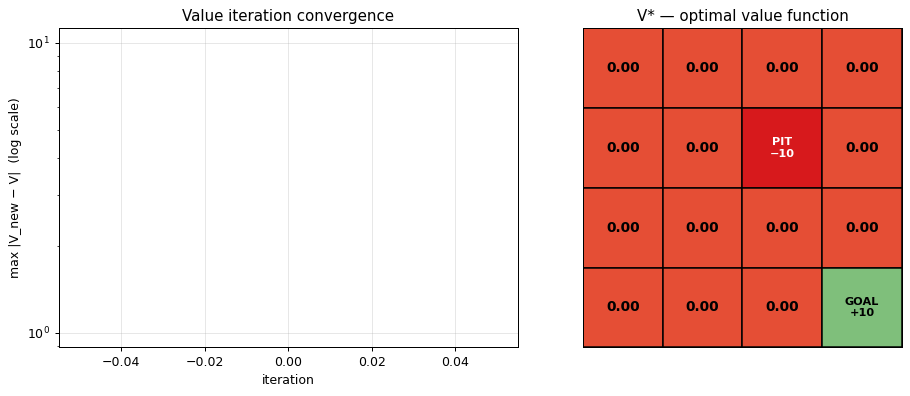

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(diffs, lw=2)
axes[0].set_yscale('log')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('max |V_new − V|  (log scale)')
axes[0].set_title('Value iteration convergence')
axes[0].grid(alpha=0.3)

plot_grid(V=V_star, title="V* — optimal value function", ax=axes[1])
plt.tight_layout()
plt.show()

### 🎯 Exercise 4 — Extract the optimal policy from $V^*$

Once we have $V^*$, the optimal policy is **easy to read off**: in each state, pick the action that maximises

$$ Q^*(s, a) \;=\; R(s, a) + \gamma\, V^*(s') $$

$Q^*(s, a)$ is called the **optimal action-value** — "what you get from taking $a$ in $s$, then acting optimally forever after".

You need to fill in the body of `extract_greedy_policy` so that each non-terminal row of `policy` has a single `1.0` at the index of the best action and zeros elsewhere.

Useful tools: `np.argmax(...)`, the `step()` function, `state_to_idx(...)`.


In [30]:
def extract_greedy_policy(V, gamma):
    """Return a deterministic policy that is greedy with respect to V.

    The output is an (N_STATES, N_ACTIONS) array. Each row has a single 1.0
    (the chosen action) and zeros elsewhere.
    """
    policy = np.zeros((N_STATES, N_ACTIONS))
    for s in range(N_STATES):
        row, col = idx_to_state(s)
        if is_terminal(row, col):
            continue

        # ============================================================
        # 🎯 YOUR CODE HERE  (~ 5–6 lines)
        # 1) compute q_values[a] = R(s,a) + γ · V(s')  for every action
        # 2) find the index of the best action (np.argmax)
        # 3) set policy[s, best_action] = 1.0

        ...
        # --- 🎯🎯🎯🎯 ---
    return policy


optimal_policy = extract_greedy_policy(V_star, GAMMA)

# Quick sanity check: from (0,0), the optimal first action must be down or right
# (both lead to the goal in 6 steps without falling into the pit).
first_action = int(np.argmax(optimal_policy[state_to_idx(0, 0)]))
print(f"From (0,0), the optimal agent chooses: {ACTION_NAMES[first_action]}")
assert first_action in (1, 2), "Hmm — the first action should be 'right' or 'down'."
print("✅ Exercise 4 passed!")

From (0,0), the optimal agent chooses: ↑ up


AssertionError: Hmm — the first action should be 'right' or 'down'.

### 🎉 Putting it all together

The plot below shows on the left the **optimal** value function with arrows for the optimal policy.
On the right, the random policy's value function for comparison. Notice how every cell on the left
is **strictly better** (greener / higher number) than the same cell on the right.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_grid(V=V_star, policy=optimal_policy,
          title="V*  and  π*  (optimal policy)", ax=axes[0])
plot_grid(V=V,
          title="V^π for the random policy", ax=axes[1])
plt.tight_layout()
plt.show()

### One last sanity check

If our Bellman code is right, then **simulating** the optimal policy and averaging the returns
should give us a number very close to $V^*((0,0))$. Let's verify.


In [ ]:
def average_return(policy, start=(0, 0), n_episodes=1000):
    returns = []
    for _ in range(n_episodes):
        _, rs = simulate(policy, start=start, max_steps=100)
        returns.append(compute_return(rs, GAMMA))
    return np.mean(returns), np.std(returns)


mean_r, std_r = average_return(random_policy)
mean_o, std_o = average_return(optimal_policy)
v_star_start  = V_star[state_to_idx(0, 0)]

print(f"Random  policy:  average return = {mean_r:6.2f}  ± {std_r:.2f}")
print(f"Optimal policy:  average return = {mean_o:6.2f}  ± {std_o:.2f}")
print(f"\nV*((0,0)) from value iteration  = {v_star_start:.2f}")
print("→ Average return of π*  ≈  V*((0,0))   ✅")

## 6. Bonus — Playing with $\gamma$

The discount factor $\gamma$ controls how *far ahead* the agent looks.

- Small $\gamma$ → short-sighted: tries to grab the closest reward, avoids only the most immediate punishment.
- Large $\gamma$ → patient: willing to take small immediate losses for bigger long-term gains.

Try changing `gamma_try` below and re-run the cell. How does the policy near the pit change?

> 🎯 **Try this (no new code needed).** Experiment to find the *smallest* value of $\gamma$ for which the
> optimal first action from `(0,0)` is still `→ right` (or `↓ down`). Below that threshold, the agent
> becomes too short-sighted to "see" the +10 reward — what does it do instead?


In [ ]:
gamma_try = 0.3    # 🎛️ try 0.1, 0.5, 0.9, 0.99 — and the threshold you found above

V_try = np.zeros(N_STATES)
for _ in range(500):
    V_new = bellman_optimality_update(V_try, gamma_try)
    if np.max(np.abs(V_new - V_try)) < 1e-9:
        break
    V_try = V_new
policy_try = extract_greedy_policy(V_try, gamma_try)

print(f"From (0,0) with γ={gamma_try}: agent chooses "
      f"{ACTION_NAMES[int(np.argmax(policy_try[state_to_idx(0,0)]))]}")

plot_grid(V=V_try, policy=policy_try,
          title=f"Optimal policy with γ = {gamma_try}")
plt.tight_layout()
plt.show()

## 🎓 Summary

You just implemented from scratch the two most fundamental algorithms in reinforcement learning:

| Algorithm | Equation | What it computes |
|---|---|---|
| **Policy evaluation** | $V^\pi(s) = \sum_a \pi(a\mid s)\big[R + \gamma V^\pi(s')\big]$ | how good policy $\pi$ is |
| **Value iteration**   | $V^*(s)   = \max_a \big[R + \gamma V^*(s')\big]$              | the best possible value |

### Key takeaways
1. The **Bellman equations** turn an infinite-horizon problem into a *recursive* one-step look-ahead.
2. **Iterating** these equations is enough to find the optimal policy — no calculus, no neural networks, just a `for` loop.
3. *Expectation* vs *optimality* — these two ideas are the backbone of virtually every RL algorithm you will see later: Q-learning, SARSA, DQN, Actor-Critic, AlphaGo, …

### Where to go next
- Make the environment **stochastic**: change `step` so that with some probability the agent slips sideways. The math has the inner $\sum_{s'} P(s' \mid s, a)\, V(s')$ for exactly this reason.
- Try **policy iteration**: alternate between evaluating the current policy and improving it greedily.
- Move to environments with **many more states**, where exact value iteration breaks down — that's when we need **function approximation** (= deep RL).

Well done! 🎉
